In [37]:
import numpy as np
# import sympy as sp
from plotly import express as px
from matplotlib import pyplot as plt
import pandas as pd
import scipy as scp


#IGUAL PARA TODOS LOS EXPERIMENTOS AL MENOS DEL MIERCOLES PASADO QSY NO CREO QUE NADIE VAYA A LEER ESTO HOLA CUCHU

f_0=16.4e3



data=pd.read_excel('dia3_distvar.ods')

In [38]:
#########FUNCIONES

def funkfit (x,a,b,c,d):
    """ a*np.sin(2 pi* b * x + c )+d """
    return a*np.sin(2*np.pi*b*x+c)+d

def B_short(x,n,a,log=False):
    if log:
        return np.exp(a)*x**n
    else:    
        return a*x**n

def lock_in(datos,f):
    x,y =datos['Second'],datos['Volt.1']
    
    # print(x,'\n',y)
    dx=x.iloc[-1]-x.iloc[0]
    
    y_cos= np.cos(2*np.pi*f*x)* y
    y_sin= np.sin(2*np.pi*f*x)* y

    U_cos=1/dx*np.trapz(y_cos,x=x)
    U_sin=1/dx*np.trapz(y_sin,x=x)

    
    # plt.figure()
    # plt.plot(y_cos)
    r=((2*U_cos)**2+(2*U_sin)**2)**.5
    phi=np.arctan2(U_sin,U_cos)

    return r,phi

In [39]:
data.columns

Index(['x', 'R mV', 'fase Deg', 'Vdet V rms', 'f (cte) kHZ',
       'dist banco cm apreciacion ponele que 1cm porque esta a ojo',
       'VRMSgen V', 'VppGen V', 'fGen KHZ', 'nroarchivo', 'd eustaquio',
       'd maria'],
      dtype='object')

In [40]:
V=data['R mV']*1e-3 # mv a V
d=data['dist banco cm apreciacion ponele que 1cm porque esta a ojo'] #tremendo nombre
d+= 7+10
d=d*1e-2
d,V=d[:4],V[:4]

d,V


(0    3.17
 1    3.67
 2    4.17
 3    4.67
 Name: dist banco cm apreciacion ponele que 1cm porque esta a ojo, dtype: float64,
 0    0.00251
 1    0.00167
 2    0.00112
 3    0.00070
 Name: R mV, dtype: float64)

Text(0, 0.5, 'Voltaje [V]')

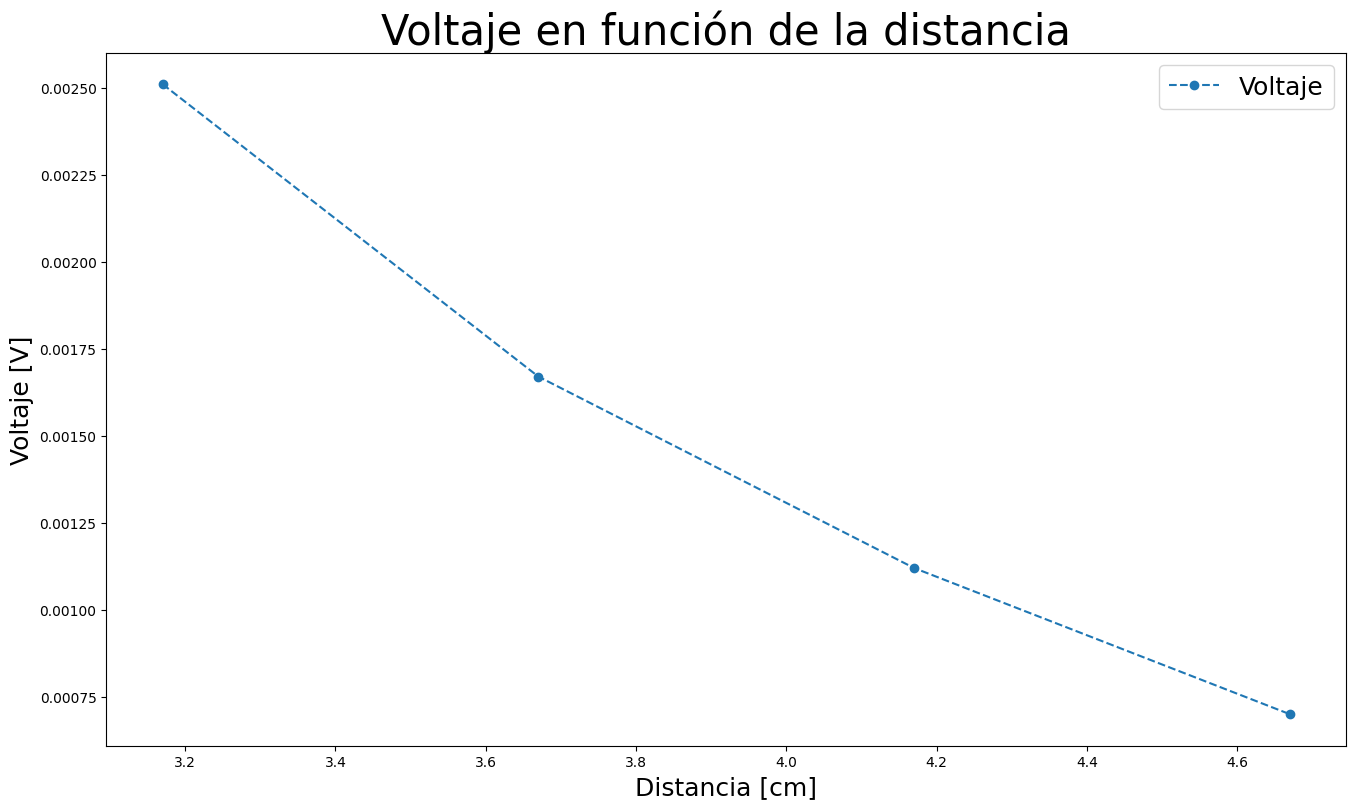

In [41]:
plt.figure(figsize=(16,9))
plt.plot(d,V,'o--')

plt.title('Voltaje en función de la distancia',fontsize=30)
plt.legend(['Voltaje'],fontsize=18)

plt.xlabel('Distancia [cm]',fontsize=18)
plt.ylabel('Voltaje [V]',fontsize=18)

In [42]:
P=np.polyfit(np.log(d[:]),np.log(V[:]),1)
#P=np.polyfit(np.log(distd2[1:-1]),np.log(V2[1:-1]),1)
P


array([-3.26244506, -2.1872567 ])

Text(0, 0.5, 'Voltaje [V]')

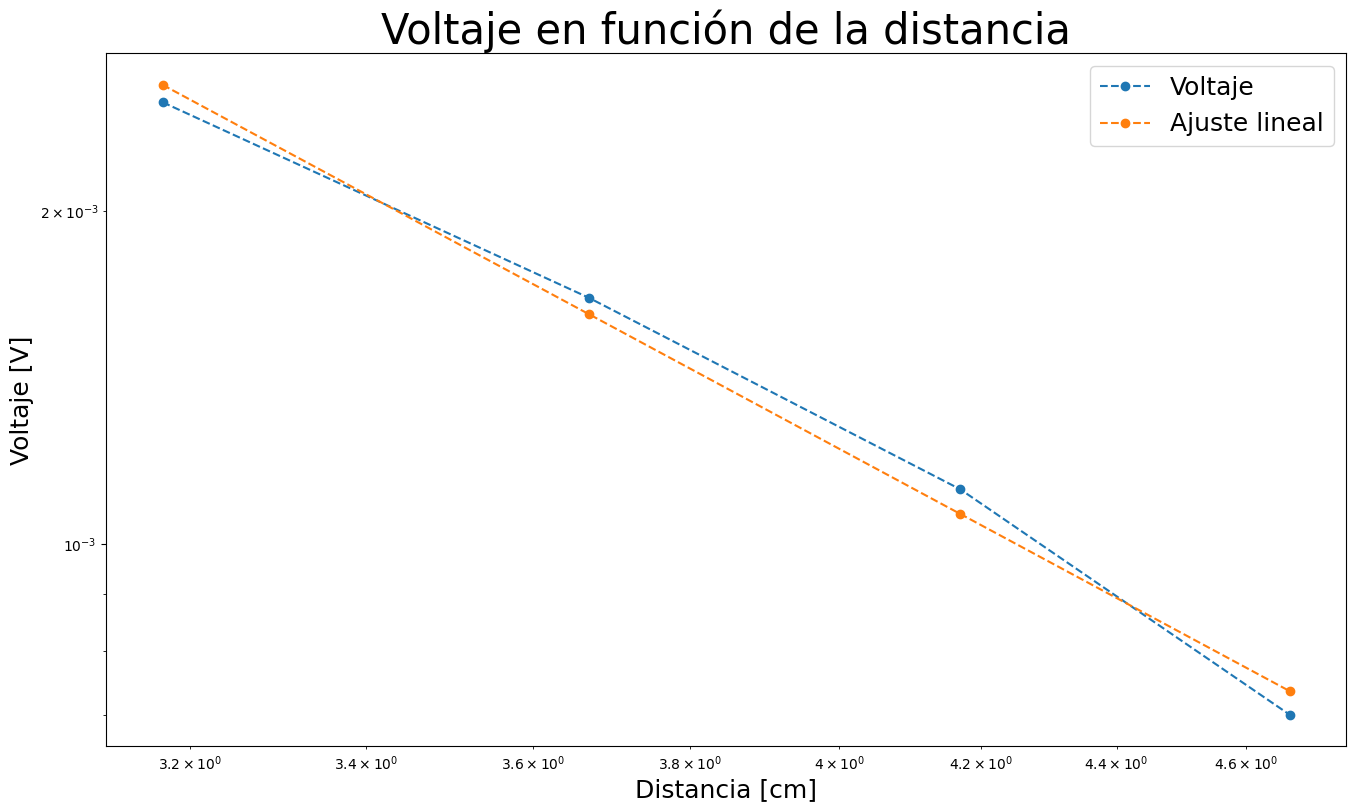

In [43]:
plt.figure(figsize=(16,9))
plt.loglog(d,V,'o--')
plt.loglog(d,B_short(d,*P,log=True),'o--')
plt.title('Voltaje en función de la distancia',fontsize=30)
plt.legend(['Voltaje','Ajuste lineal'],fontsize=18)

plt.xlabel('Distancia [cm]',fontsize=18)
plt.ylabel('Voltaje [V]',fontsize=18)

In [44]:
pd.DataFrame({'d':d,'V':V}).to_csv('V_3.csv',index=False)